In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

ROOT = Path("/Users/alexgonzalez/Documents/nba_quant")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features.minutes.rolling import prior_ewm, prior_expanding, prior_shift
from src.features.points import add_points_features

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)


In [2]:
s20 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2019-20/regular_season/player_gamelogs.parquet')
s21 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2020-21/regular_season/player_gamelogs.parquet')
s22 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2021-22/regular_season/player_gamelogs.parquet')
s23 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2022-23/regular_season/player_gamelogs.parquet')
s24 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2023-24/regular_season/player_gamelogs.parquet')
s25 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2024-25/regular_season/player_gamelogs.parquet')
s26 = pd.read_parquet('/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2025-26/regular_season/player_gamelogs.parquet')
df = pd.concat([s20, s21, s22, s23, s24, s25, s26])
df['starting'] = (
    df['start_position'].astype('string').str.strip().isin(['G', 'F', 'C']).astype(int)
)
df['minutes'] = df['minutes'].astype(float)
df['pts_per_min'] = df['pts'] / df['minutes']
print(f"Number of rows: {len(df)}")
print(f"Number of columns: {len(df.columns)}")
df.sample(5)


Number of rows: 176738
Number of columns: 191


,season_year,player_id,player_name,nickname,team_id,team_abbreviation,team_name,game_id,game_date,matchup,wl,min,fgm,fga,fg_pct,fg3_m,fg3_a,fg3_pct,ftm,fta,ft_pct,oreb,dreb,reb,ast,tov,stl,blk,blka,pf,pfd,pts,plus_minus,nba_fantasy_pts,dd2,td3,wnba_fantasy_pts,fp_high_score,available_flag,min_sec,team_count,e_off_rating,off_rating,sp_work_off_rating,e_def_rating,def_rating,sp_work_def_rating,e_net_rating,net_rating,sp_work_net_rating,ast_pct,ast_to,ast_ratio,oreb_pct,dreb_pct,reb_pct,tm_tov_pct,e_tov_pct,efg_pct,ts_pct,usg_pct,e_usg_pct,e_pace,pace,pace_per40,sp_work_pace,pie,poss,fgm_pg,fga_pg,team_city,team_tricode,team_slug,first_name,family_name,name_i,player_slug,start_position,comment,jersey_num,minutes,spd,dist,orbc,drbc,rbc,tchs,sast,ftast,pass,assists,cfgm,cfga,cfg_pct,ufgm,ufga,uncontested_field_goals_percentage,field_goal_percentage,dfgm,dfga,dfg_pct,team_fgm,team_fga,team_fg_pct,team_fg3_m,team_fg3_a,team_fg3_pct,team_ftm,team_fta,team_ft_pct,team_oreb,team_dreb,team_reb,team_ast,team_tov,team_stl,team_blk,team_blka,team_pf,team_pfd,team_pts,team_plus_minus,team_e_off_rating,team_off_rating,team_e_def_rating,team_def_rating,team_e_net_rating,team_net_rating,team_ast_pct,team_ast_to,team_ast_ratio,team_oreb_pct,team_dreb_pct,team_reb_pct,team_tm_tov_pct,team_efg_pct,team_ts_pct,team_e_pace,team_pace,team_pace_per40,team_poss,team_pie,opp_team_id,opp_fgm,opp_fga,opp_fg_pct,opp_fg3_m,opp_fg3_a,opp_fg3_pct,opp_ftm,opp_fta,opp_ft_pct,opp_oreb,opp_dreb,opp_reb,opp_ast,opp_tov,opp_stl,opp_blk,opp_blka,opp_pf,opp_pfd,opp_pts,opp_plus_minus,opp_e_off_rating,opp_off_rating,opp_e_def_rating,opp_def_rating,opp_e_net_rating,opp_net_rating,opp_ast_pct,opp_ast_to,opp_ast_ratio,opp_oreb_pct,opp_dreb_pct,opp_reb_pct,opp_tm_tov_pct,opp_efg_pct,opp_ts_pct,opp_e_pace,opp_pace,opp_pace_per40,opp_poss,opp_pie,season_type,pos,game_total,team_spread,player_team_spread,starting,pts_per_min
2192,2021-22,1629833,Keljin Blevins,Keljin,1610612757,POR,Portland Trail Blazers,0022101130,2022-03-28T00:00:00,POR vs. OKC,L,20.575000,4,10,0.400,2,7,0.286,0,0,0.0,3,4,7,0,3,1,0,0,2,0,10,1,18.4,0,0,21.0,20.0,1,20:35,1,125.0,120.0,120.0,115.6,117.8,117.8,9.4,2.2,2.2,0.000,0.0,0.0,0.143,0.200,0.171,23.1,23.1,0.500,0.500,0.250,0.264,103.86,104.98,87.48,104.98,0.055,45,4.0,10.0,Portland,POR,blazers,Keljin,Blevins,K. Blevins,keljin-blevins,,,21,20.575000,4.66,1.67,4,8,11,31,0,0,19,0,2,3,0.667,2,7,0.286,0.400,1,2,0.500,51,112,0.455,20,50,0.400,9,13,0.692,19,28,47,28,11.0,17,5,3,23,15,131,-3.0,119.4,120.2,120.7,126.4,-1.3,-6.2,0.549,2.55,17.6,0.381,0.660,0.500,0.101,0.545,0.556,99.9,97.36,81.13,109,0.468,1610612760,48,90,0.533,20,45,0.444,18,25,0.720,11,38,49,32,21.0,7,3,5,15,23,134,3.0,120.7,126.4,119.4,120.2,1.3,6.2,0.667,1.52,20.8,0.340,0.619,0.500,0.198,0.644,0.663,99.9,97.36,81.13,106,0.532,Regular Season,SF,220.5,1.5,1.5,0,0.486027
17782,2023-24,202696,Nikola Vučević,Nikola,1610612741,CHI,Chicago Bulls,0022300370,2023-12-20T00:00:00,CHI vs. LAL,W,30.936667,4,13,0.308,3,5,0.600,2,2,1.0,1,9,10,2,1,1,1,0,2,2,13,6,33.0,1,0,32.0,33.0,1,30:56,1,121.1,121.2,121.2,105.1,108.8,108.8,16.0,12.4,12.4,0.077,2.0,11.8,0.033,0.273,0.159,5.9,5.9,0.423,0.468,0.205,0.204,105.88,103.95,86.63,103.95,0.089,66,4.0,13.0,Chicago,CHI,bulls,Nikola,Vučević,N. Vučević,nikola-vučević,C,,9,30.936667,4.12,2.24,1,11,12,59,2,0,43,2,1,4,0.250,3,9,0.333,0.308,7,8,0.875,48,88,0.545,18,34,0.529,10,11,0.909,7,41,48,25,16.0,7,6,7,15,11,124,16.0,121.8,120.4,101.3,104.9,20.4,15.5,0.521,1.56,18.4,0.200,0.788,0.533,0.155,0.648,0.668,104.2,103.00,85.83,103,0.564,1610612747,42,94,0.447,12,37,0.324,12,15,0.800,8,32,40,27,14.0,7,7,6,11,15,108,-16.0,101.3,104.9,121.8,120.4,-20.4,-15.5,0.643,1.93,19.3,0.212,0.800,0.467,0.136,0.511,0.537,104.2,103.00,85.83,103,0.436,Regular Season,C,225.0,3.5,3.5,1,0.420213
2667,2025-26,1629610,DaQuan Jeffries,DaQuan,1610612758,SAC,Sacramento Kings,0022501078,2026-03-28T00:00:00,SAC @ ATL,L,26.533333,6,9,0.667,2,3,0.667,1,1,1.0,2,1,3,1,0,0,0,1,0,2,15,8,20.1,0,0,21.0,20.0

In [3]:
print(f"Total number of duplicates: {df.duplicated(subset=['game_id', 'player_id']).sum()}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df = add_points_features(df)

Total number of duplicates: 0
Rows: 176738
Columns: 191


In [4]:
PTS_FEATURES = [
    "pts_per_min_10",
    "pts_per_min_20",
    "season_pts_per_min",
    "current_team_pts_per_min",
    "ppm_10_minus_season",
    "fta_per_min_10",
    "fg3a_per_min_10",
    "ts_agg_20",
    "usg_wmean_10",
    "player_fga_share_10",
    "min_mean_10",
    "starting",
    "implied_team_total",
    "team_spread_canonical",
    "expected_possessions",
    "opp_def_rating_mean_10",
    "season_appearances_prior",
    "current_team_rows_prior",
]
_EXCLUDED_FEATURES = {"minutes", "pts", "predicted_minutes_oof"}
leaked = _EXCLUDED_FEATURES.intersection(PTS_FEATURES)
if leaked:
    raise AssertionError(f"Game-N outcomes leaked into features: {sorted(leaked)}")
missing = [column for column in PTS_FEATURES if column not in df.columns]
if missing:
    raise KeyError(f"Rate features missing from the panel: {missing}")
print(f"Number of features: {len(PTS_FEATURES)}")
PTS_FEATURES


Number of features: 18


['pts_per_min_10',
 'pts_per_min_20',
 'season_pts_per_min',
 'current_team_pts_per_min',
 'ppm_10_minus_season',
 'fta_per_min_10',
 'fg3a_per_min_10',
 'ts_agg_20',
 'usg_wmean_10',
 'player_fga_share_10',
 'min_mean_10',
 'starting',
 'implied_team_total',
 'team_spread_canonical',
 'expected_possessions',
 'opp_def_rating_mean_10',
 'season_appearances_prior',
 'current_team_rows_prior']

In [5]:
# ── Prop-specific config (capped points per minute) ─────────────────────

HOLDOUT_SEASON = "2025-26"
ID_COLS = ["game_id", "player_id", "season_year", "player_name", "game_date"]
RATE_CAP = 6.0
TARGET_COL = "pts_per_min"
ROLE_COL = "starting"

QUANTILES = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95]

# Starting point is the minutes quantile search. The next code cell replaces
# these with tune_xgb_quantile on the pre-holdout pool only.
XGB_PARAMS = dict(
    objective="reg:quantileerror",
    n_estimators=1695,
    max_depth=3,
    learning_rate=0.052852647946832816,
    subsample=0.5916232263322159,
    colsample_bytree=0.6284413523882679,
    reg_alpha=0.022871045941195746,
    reg_lambda=2.0960269065270034,
    min_child_weight=8,
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=50,
)

ARTIFACT_STEM = "pts_nba_model"

# ── Shared train/eval helpers ─────────────────────────────────────────────────
from models.shared.splits import prepare_splits
from models.shared.train import run_timeseries_cv, run_walk_forward, evaluate_holdout
from models.shared.analysis import run_feature_ablation, analyze_correlations
from models.shared.artifacts import save_model_bundle, load_model_bundle, predict_quantiles
from models.shared.metrics import interval_coverage, pinball_50, pinball_loss
from models.shared.oos import capped_rate


In [6]:
df = df.loc[df["minutes"] > 0].copy()
df = df.sort_values(
    ["game_date", "game_id", "player_id"], kind="mergesort"
).reset_index(drop=True)
df[TARGET_COL] = capped_rate(df["pts"], df["minutes"], cap=RATE_CAP)
# Naive baselines for the rate label. Not model features.
df["pts_per_min_lag_1"] = prior_shift(df, TARGET_COL, ["player_id"])
df["pts_per_min_ewm_hl_3"] = prior_ewm(
    df, TARGET_COL, ["player_id"], halflife=3
)
df["season_pts_per_min_mean"] = prior_expanding(
    df, TARGET_COL, ["player_id", "season_year"], "mean"
)
print(f"After filtering appearances: {df[PTS_FEATURES].shape[0]} rows")
print(df[TARGET_COL].describe().round(3))


After filtering appearances: 176710 rows
count    176710.000
mean          0.428
std           0.295
min           0.000
25%           0.229
50%           0.409
75%           0.597
max           6.000
Name: pts_per_min, dtype: float64


In [7]:
splits = prepare_splits(
    df,
    holdout_season=HOLDOUT_SEASON,
    features=PTS_FEATURES,
    target_col=TARGET_COL,
    id_cols=ID_COLS,
    role_col=ROLE_COL,
    extra_keep=[
        "minutes",
        "pts",
        "pts_per_min_lag_1",
        "season_pts_per_min_mean",
        "pts_per_min_ewm_hl_3",
    ],
)
ppm_df = splits["ppm_df"]
ppm_holdout = splits["ppm_holdout"]
X = splits["X"]
y = splits["y"]


Train pool (excl. 2025-26) : 150,062 rows
Holdout   (2025-26)        : 26,648 rows
Date range (train)   : 2019-10-22 → 2025-04-13
Date range (holdout) : 2025-10-21 → 2026-04-12


In [8]:
# from models.shared.train import tune_xgb_quantile

# # X and y are the pre-holdout pool from prepare_splits. The holdout frame
# # is not passed in.
# result = tune_xgb_quantile(X, y, n_trials=100, n_splits=5)
# XGB_PARAMS = result["best_params"]


In [9]:
# The retune above is the hyperparameter search (q50, TimeSeriesSplit,
# pre-holdout only). This walk-forward fits every quantile on the same pool.
wf = run_walk_forward(
    X, y, ppm_df,
    xgb_params=XGB_PARAMS,
    role_col=ROLE_COL,
    tiers={},
    quantiles=QUANTILES,
)

wf_results = wf["wf_results"]
models_last = wf["models_last"]
preds_last = wf["preds_last"]
X_val_last = wf["X_val_last"]
y_val_last = wf["y_val_last"]
starting_last = wf["starting_last"]
last_fold = wf["last_fold"]



── Phase 2: Walk-Forward Validation (date-based) ───────────────────
Unique game dates in pool : 942
Training window           : 471 dates (~50%)
Step size                 : 94 dates (~10%)

WF fold 1  (2022-11-02 → 2023-02-07)
  n=14737
  pinball  | q0.05=0.018  q0.10=0.034  q0.20=0.058  q0.30=0.076  q0.40=0.087  q0.50=0.092  q0.60=0.091  q0.70=0.085  q0.80=0.071  q0.90=0.048  q0.95=0.030
  coverage | 80%=80.8% (target 80%)  90%=90.6% (target 90%)
  Starters   | n= 7030 | pinball q50: 0.075 | 80% coverage: 80.3%
  Bench      | n= 7707 | pinball q50: 0.107 | 80% coverage: 81.2%

WF fold 2  (2023-02-07 → 2023-12-05)
  n=14919
  pinball  | q0.05=0.019  q0.10=0.034  q0.20=0.059  q0.30=0.077  q0.40=0.088  q0.50=0.094  q0.60=0.093  q0.70=0.086  q0.80=0.072  q0.90=0.048  q0.95=0.031
  coverage | 80%=80.5% (target 80%)  90%=91.1% (target 90%)
  Starters   | n= 7050 | pinball q50: 0.077 | 80% coverage: 80.0%
  Bench      | n= 7869 | pinball q50: 0.109 | 80% coverage: 81.0%

WF fold 3  (2023-1

### Evaluation

XGBoost quantile models only. Each split is scored with pinball loss at every trained quantile and with interval coverage for the 80% interval (q0.10–q0.90) and the 90% interval (q0.05–q0.95). The holdout also reports empirical calibration at each quantile, P(y ≤ q̂), interval sharpness as the mean and median width in points per minute, the share of rows where a lower quantile exceeds a higher one, and rate tiers bucketed by predicted q50 rather than actual rate.


In [10]:
def score_predictions(y_true, preds, split: str):
    """Pinball loss per quantile and central interval coverage."""
    y_true = np.asarray(y_true, dtype=float)
    pinball_rows = []
    for key, pred in preds.items():
        alpha = float(str(key).split("_", 1)[1])
        pinball_rows.append({
            "split": split,
            "quantile": alpha,
            "pinball": pinball_loss(y_true, pred, alpha),
        })
    coverage_rows = []
    for low, high, nominal in ((0.10, 0.90, 0.80), (0.05, 0.95, 0.90)):
        low_key, high_key = f"q_{low:.2f}", f"q_{high:.2f}"
        if low_key not in preds or high_key not in preds:
            continue
        coverage_rows.append({
            "split": split,
            "interval": f"{nominal:.0%}",
            "coverage": interval_coverage(y_true, preds[low_key], preds[high_key]),
            "target": nominal,
        })
    return pd.DataFrame(pinball_rows), pd.DataFrame(coverage_rows)


wf_pinball, wf_coverage = score_predictions(
    y_val_last, preds_last, last_fold["fold"]
)
display(wf_pinball.round(4))
display(wf_coverage.round(4))


,split,quantile,pinball
0,WF fold 4 (2024-03-17 → 2025-01-02),0.05,0.0182
1,WF fold 4 (2024-03-17 → 2025-01-02),0.10,0.0334
2,WF fold 4 (2024-03-17 → 2025-01-02),0.20,0.0582
3,WF fold 4 (2024-03-17 → 2025-01-02),0.30,0.0766
4,WF fold 4 (2024-03-17 → 2025-01-02),0.40,0.0892
5,WF fold 4 (2024-03-17 → 2025-01-02),0.50,0.0957
6,WF fold 4 (2024-03-17 → 2025-01-02),0.60,0.0957
7,WF fold 4 (2024-03-17 → 2025-01-02),0.70,0.0889
8,WF fold 4 (2024-03-17 → 2025-01-02),0.80,0.0747
9,WF fold 4 (2024-03-17 → 2025-01-02),0.90,0.0506


,split,interval,coverage,target
0,WF fold 4 (2024-03-17 → 2025-01-02),80%,0.8032,0.8
1,WF fold 4 (2024-03-17 → 2025-01-02),90%,0.9074,0.9



── q_0.05 ──


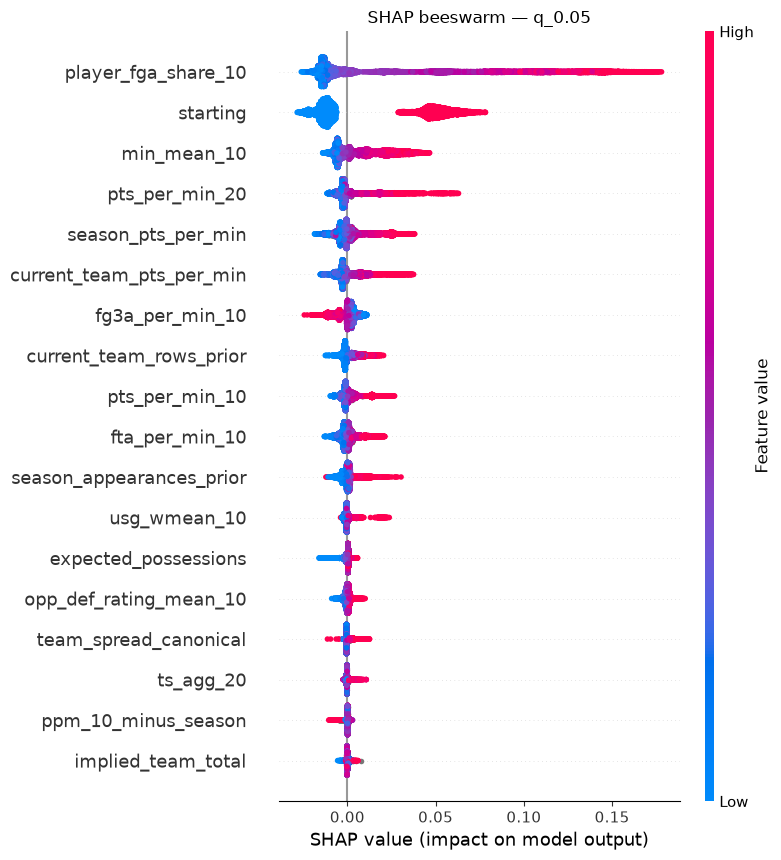


── q_0.10 ──


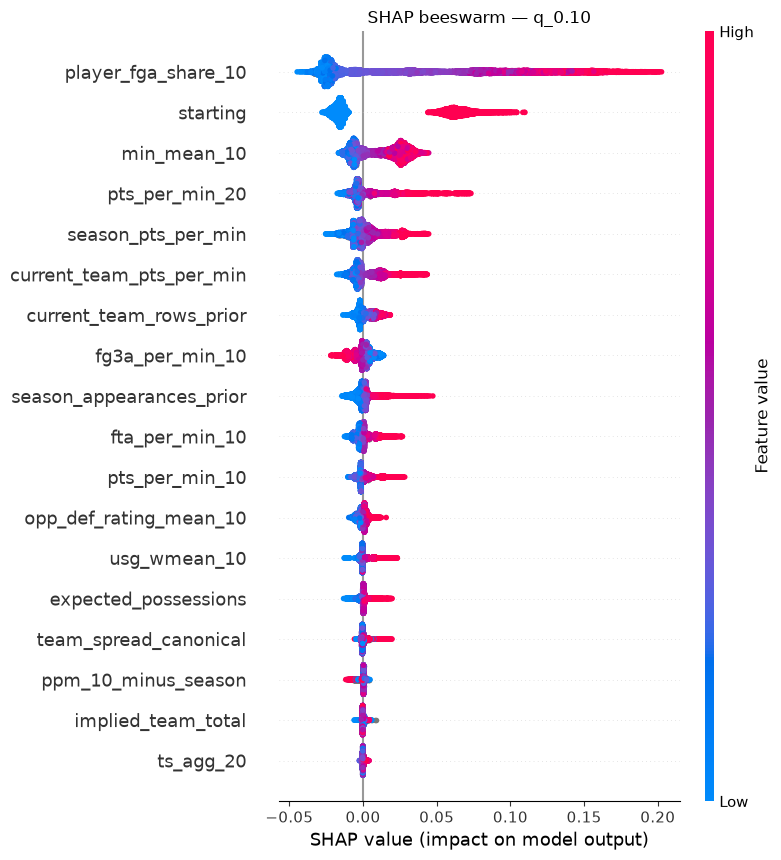


── q_0.20 ──


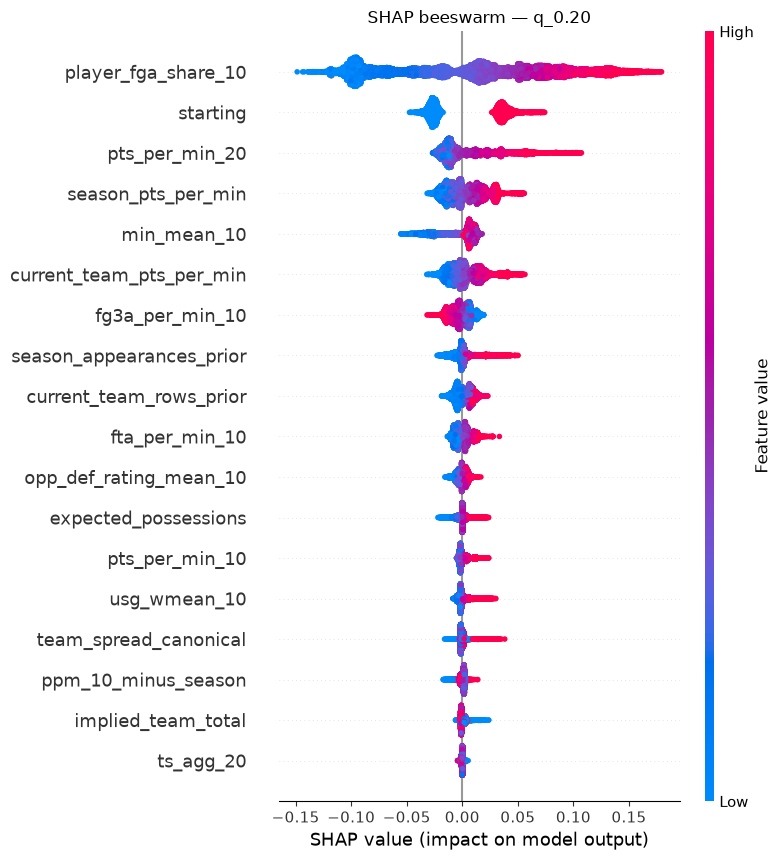


── q_0.30 ──


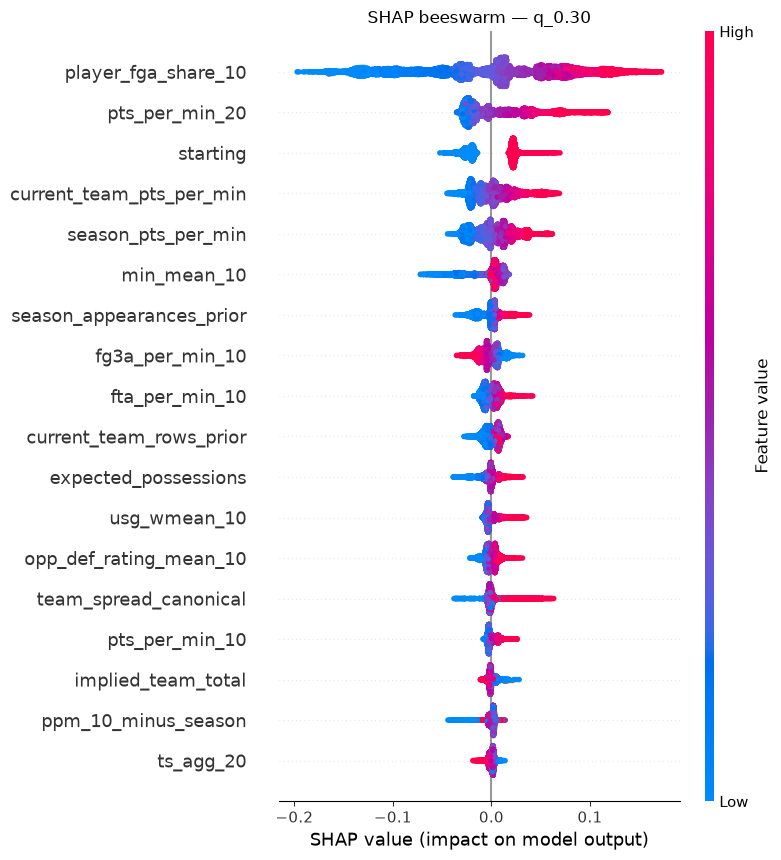


── q_0.40 ──


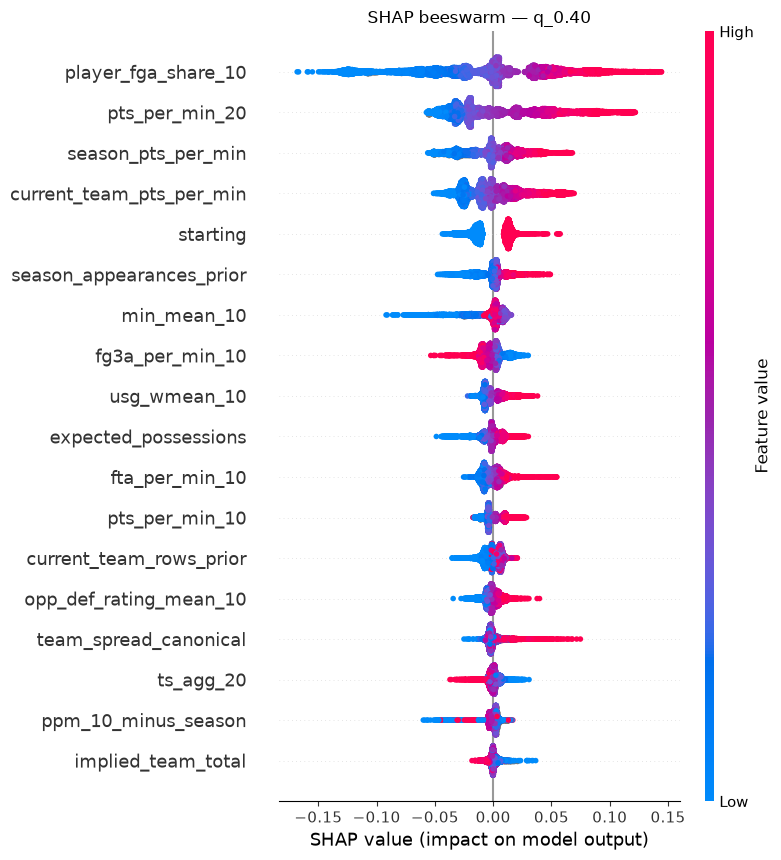


── q_0.50 ──


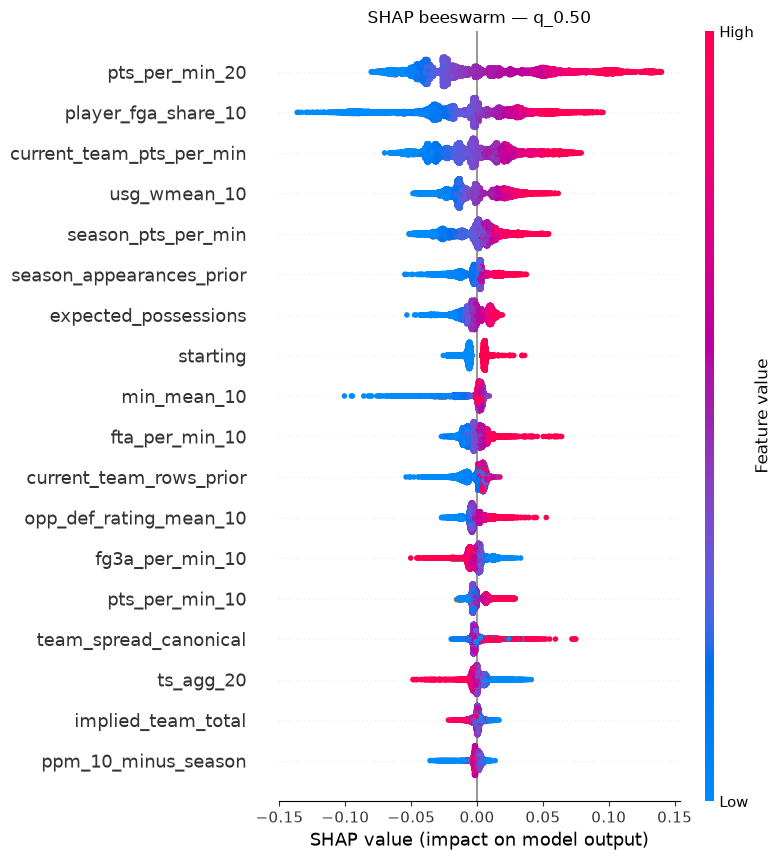


── q_0.60 ──


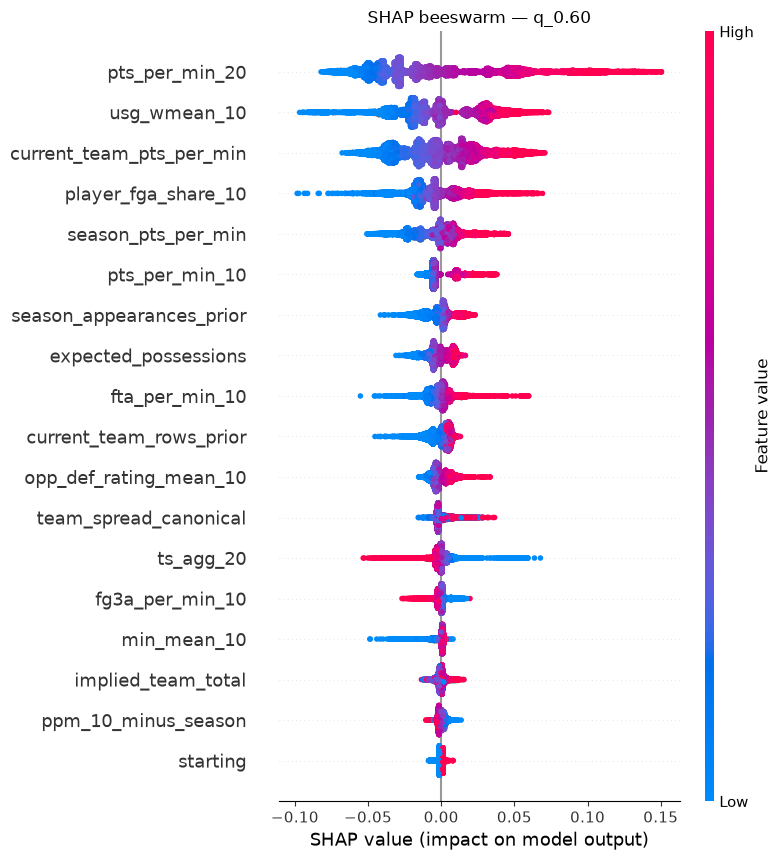


── q_0.70 ──


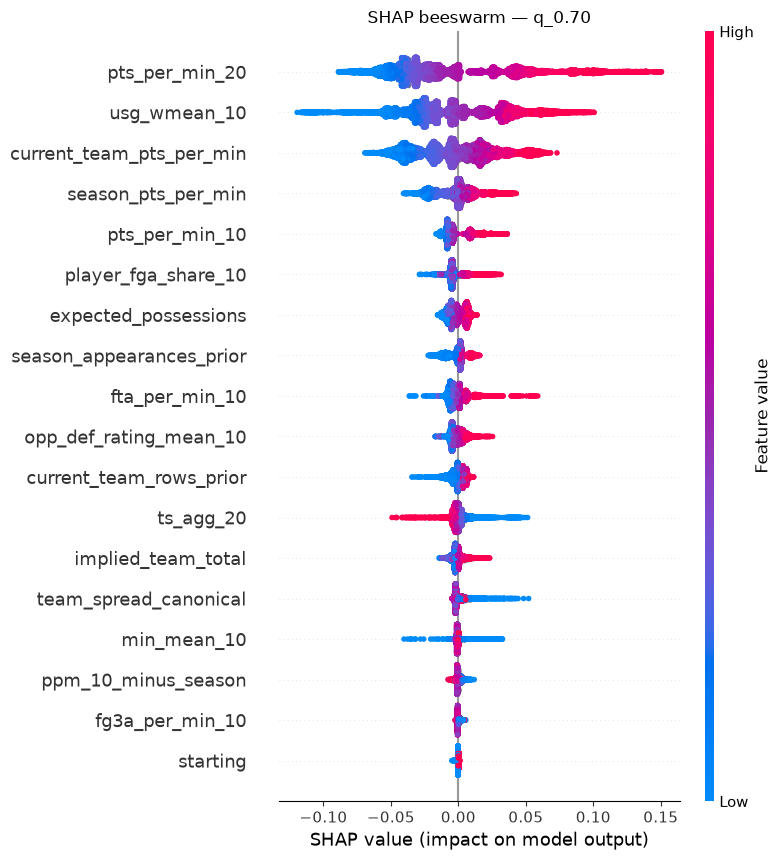


── q_0.80 ──


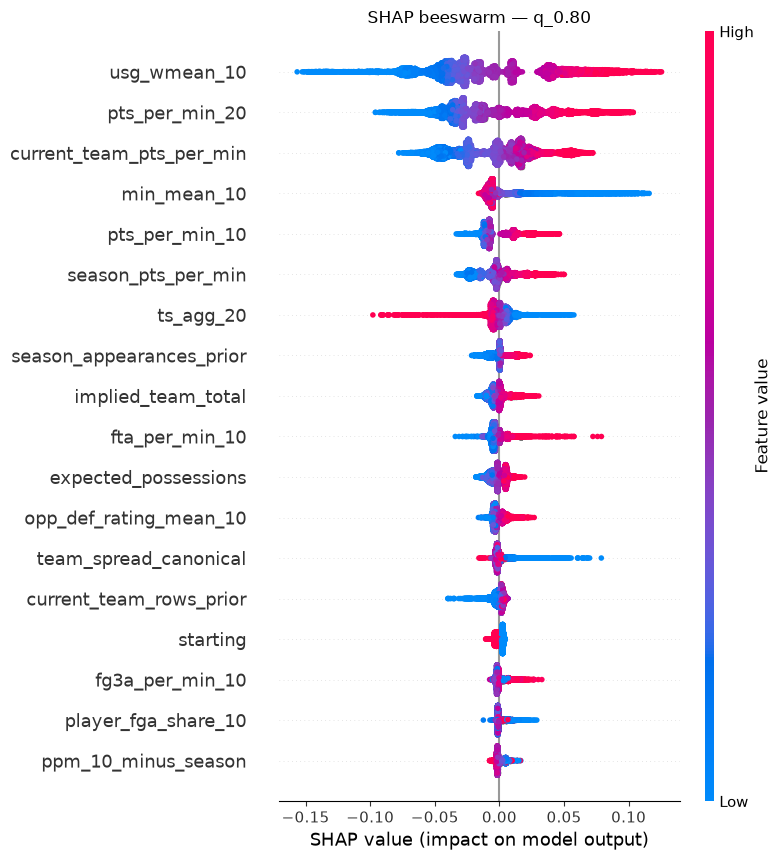


── q_0.90 ──


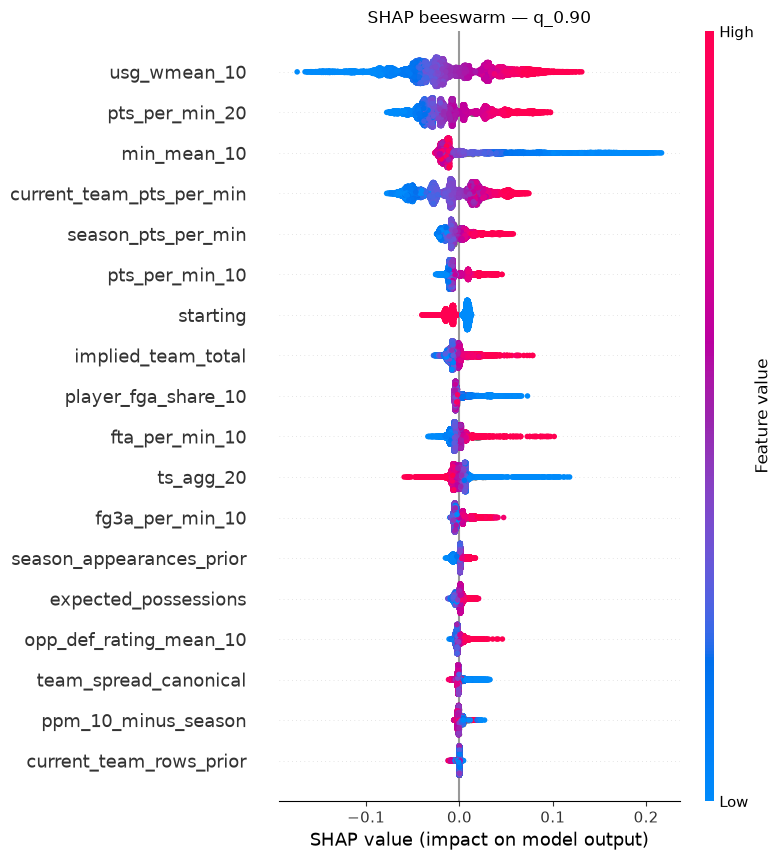


── q_0.95 ──


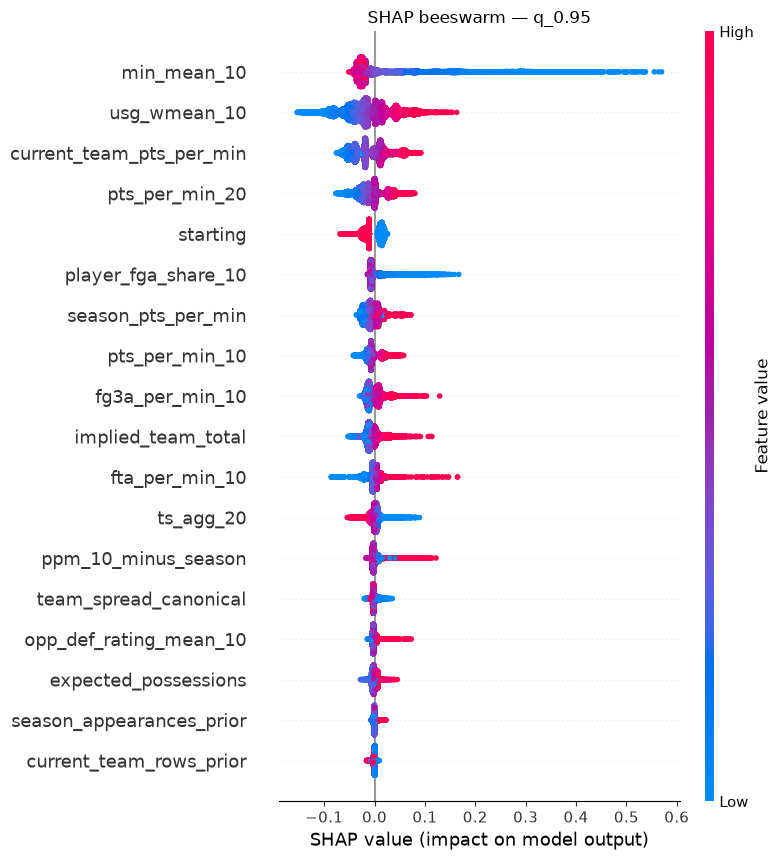

In [11]:
import shap

for q_key, model in models_last.items():
    explainer = shap.TreeExplainer(model, model_output="raw")
    shap_values = explainer(X_val_last)
    print(f"\n── {q_key} ──")
    shap.plots.beeswarm(shap_values, max_display=30, show=False)
    plt.title(f"SHAP beeswarm — {q_key}")
    plt.tight_layout()
    plt.show()


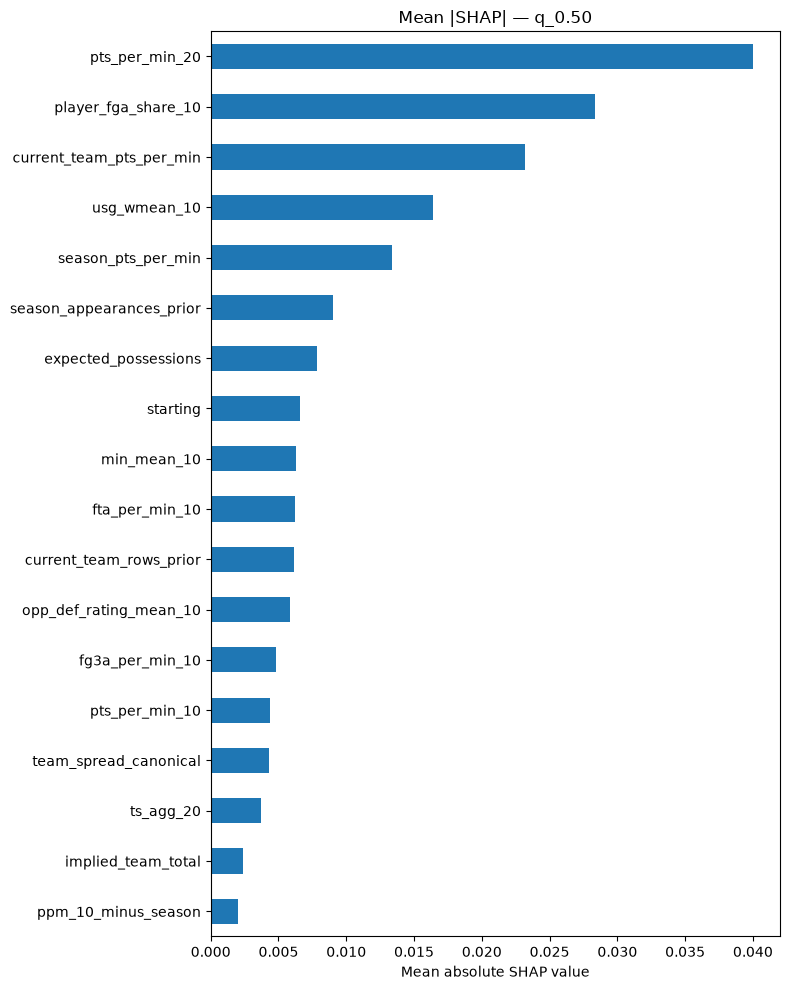

In [12]:
model = models_last["q_0.50"]
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_val_last)

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
feat_imp = pd.Series(mean_abs_shap, index=PTS_FEATURES).sort_values(ascending=True)

ax = feat_imp.plot(kind="barh", figsize=(8, 10))
ax.set_title("Mean |SHAP| — q_0.50")
ax.set_xlabel("Mean absolute SHAP value")
plt.tight_layout()
plt.show()


In [13]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer
from scipy import stats as sp_stats

result = permutation_importance(
    models_last["q_0.50"],
    X_val_last,
    y_val_last,
    n_repeats=30,
    random_state=42,
    scoring=make_scorer(pinball_50),
)

pi_df = (
    pd.DataFrame({
        "feature": X_val_last.columns,
        "importance": result.importances_mean,
        "std": result.importances_std,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
pi_df.index += 1
pi_df["importance"] = pi_df["importance"].round(5)
pi_df["std"] = pi_df["std"].round(5)
pi_df["p_value"] = sp_stats.ttest_1samp(result.importances, 0.0, axis=1).pvalue.round(4)
pi_df["significant"] = pi_df["p_value"] < 0.05

print("Permutation importance (val set) — higher = more important, significant = p<0.05")
print(pi_df.to_string())


Permutation importance (val set) — higher = more important, significant = p<0.05
                     feature  importance      std  p_value  significant
1             pts_per_min_20     0.00357  0.00015      0.0         True
2        player_fga_share_10     0.00255  0.00013      0.0         True
3   current_team_pts_per_min     0.00152  0.00010      0.0         True
4               usg_wmean_10     0.00084  0.00008      0.0         True
5         season_pts_per_min     0.00063  0.00007      0.0         True
6                min_mean_10     0.00042  0.00004      0.0         True
7    current_team_rows_prior     0.00023  0.00003      0.0         True
8       expected_possessions     0.00022  0.00004      0.0         True
9                   starting     0.00021  0.00005      0.0         True
10  season_appearances_prior     0.00021  0.00006      0.0         True
11    opp_def_rating_mean_10     0.00015  0.00004      0.0         True
12     team_spread_canonical     0.00015  0.00004      

In [14]:
train_mask_last = last_fold["train_mask"]
val_mask_last = last_fold["val_mask"]
X_tr_last = X[train_mask_last]
X_va_last = X[val_mask_last]
y_tr_last = y[train_mask_last]
y_va_last = y[val_mask_last]

ablation_df = run_feature_ablation(
    PTS_FEATURES, X_tr_last, y_tr_last, X_va_last, y_va_last,
    xgb_params=XGB_PARAMS,
)


Baseline pinball q50 (all features): 0.0957
                     feature  ablated_pinball  delta_pinball
1   current_team_pts_per_min           0.0959         0.0002
2    current_team_rows_prior           0.0958         0.0001
3                min_mean_10           0.0957         0.0001
4     opp_def_rating_mean_10           0.0958         0.0001
5             pts_per_min_20           0.0958         0.0001
6   season_appearances_prior           0.0957         0.0000
7       expected_possessions           0.0957         0.0000
8      team_spread_canonical           0.0957         0.0000
9         implied_team_total           0.0957        -0.0000
10                  starting           0.0957         0.0000
11            pts_per_min_10           0.0957        -0.0000
12              usg_wmean_10           0.0957         0.0000
13                 ts_agg_20           0.0957        -0.0000
14           fg3a_per_min_10           0.0957         0.0000
15            fta_per_min_10           0.

In [15]:
from scipy import stats

model = models_last["q_0.50"]
_shap_expl = shap.TreeExplainer(model, model_output="raw")
_shap_vals = _shap_expl(X_val_last)
_mean_abs_shap = np.abs(_shap_vals.values).mean(axis=0)

shap_table = pd.DataFrame({
    "feature": X_val_last.columns,
    "mean_abs_shap": _mean_abs_shap,
}).assign(shap_rank=lambda d: d["mean_abs_shap"].rank(method="min", ascending=False).astype(int))

perm_table = (
    pi_df.sort_values("importance", ascending=False)
    .reset_index(drop=True)
    .rename(columns={"importance": "perm_importance", "std": "perm_importance_std"})
)
perm_table["perm_rank"] = np.arange(1, len(perm_table) + 1)
perm_table = perm_table[["feature", "perm_rank", "perm_importance", "perm_importance_std"]]

perm_pv = pd.DataFrame({
    "feature": X_val_last.columns,
    "perm_pvalue": stats.ttest_1samp(result.importances, 0.0, axis=1, nan_policy="omit").pvalue,
})

abla = ablation_df[["feature", "delta_pinball"]].rename(columns={"delta_pinball": "ablation_delta"})

feature_audit = (
    pd.DataFrame({"feature": PTS_FEATURES})
    .merge(shap_table, on="feature", how="left")
    .merge(perm_table, on="feature", how="left")
    .merge(perm_pv, on="feature", how="left")
    .merge(abla, on="feature", how="left")
)

_ms = feature_audit["mean_abs_shap"].astype(float)
_mp = feature_audit["perm_importance"].astype(float)
_max_shap = _ms.fillna(0).max()
_max_perm = _mp.fillna(0).max()
feature_audit["shap_norm"] = np.where(_max_shap > 0, _ms.fillna(0) / _max_shap, 0.0)
feature_audit["perm_norm"] = np.where(_max_perm > 0, _mp.fillna(0) / _max_perm, 0.0)
feature_audit["consensus"] = (feature_audit["shap_norm"] + feature_audit["perm_norm"]) / 2
feature_audit = feature_audit.sort_values("consensus", ascending=False).reset_index(drop=True)
feature_audit.index += 1
feature_audit["keep"] = (feature_audit["perm_pvalue"] < 0.05) & (feature_audit["ablation_delta"] > 0)

print(feature_audit.to_string())


                     feature  mean_abs_shap  shap_rank  perm_rank  perm_importance  perm_importance_std   perm_pvalue  ablation_delta  shap_norm  perm_norm  consensus   keep
1             pts_per_min_20       0.039998          1          1          0.00357              0.00015  7.641422e-42          0.0001   1.000000   1.000000   1.000000   True
2        player_fga_share_10       0.028337          2          2          0.00255              0.00013  5.594735e-39         -0.0000   0.708458   0.714286   0.711372  False
3   current_team_pts_per_min       0.023185          3          3          0.00152              0.00010  8.612103e-36          0.0002   0.579660   0.425770   0.502715   True
4               usg_wmean_10       0.016369          4          4          0.00084              0.00008  1.095996e-30          0.0000   0.409249   0.235294   0.322272  False
5         season_pts_per_min       0.013355          5          5          0.00063              0.00007  1.186945e-29         -0.0

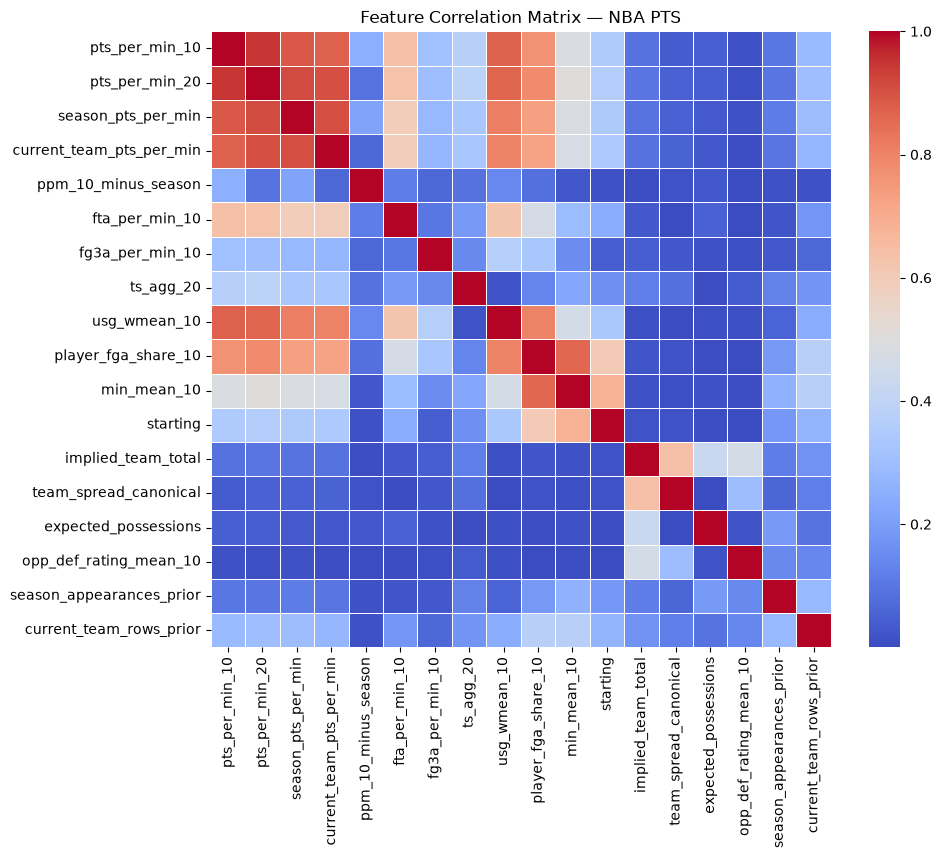

--- High Correlation Report (Threshold > 0.95) ---
No features exceed the correlation threshold.


[]

In [16]:
correlated_features = analyze_correlations(
    df, PTS_FEATURES, title="Feature Correlation Matrix — NBA PTS"
)
correlated_features


In [17]:
holdout = evaluate_holdout(
    ppm_df,
    ppm_holdout,
    features=PTS_FEATURES,
    target_col=TARGET_COL,
    xgb_params=XGB_PARAMS,
    role_col=ROLE_COL,
    tiers={},
    wf_results=wf_results,
    quantiles=QUANTILES,
    fold_label=f"{HOLDOUT_SEASON} Blind Holdout",
)
models_ho = holdout["models_ho"]
preds_ho = holdout["preds_ho"]
ho_metrics = holdout["ho_metrics"]
X_ho = holdout["X_ho"]
y_ho = holdout["y_ho"]

ho_pinball, ho_coverage = score_predictions(
    y_ho, preds_ho, f"{HOLDOUT_SEASON} holdout"
)
display(ho_pinball.round(4))
display(ho_coverage.round(4))


── 2025-26 Blind Holdout ─────────────────────────────────────────────────
  Train pool: 90% rows for fit, remainder for early-stopping only; predict holdout (never in eval_set).

2025-26 Blind Holdout
  n=26648
  pinball  | q0.05=0.019  q0.10=0.035  q0.20=0.060  q0.30=0.078  q0.40=0.090  q0.50=0.095  q0.60=0.095  q0.70=0.087  q0.80=0.073  q0.90=0.049  q0.95=0.031
  coverage | 80%=79.9% (target 80%)  90%=90.6% (target 90%)
  Starters   | n=12300 | pinball q50: 0.079 | 80% coverage: 78.9%
  Bench      | n=14348 | pinball q50: 0.109 | 80% coverage: 80.8%

───────────────────────────────────────────────────────
  Walk-forward pinball q50 (mean) : 0.094
  Holdout pinball q50             : 0.095
  Pinball gap                     : +0.001  ✓ acceptable
  Walk-forward 80% coverage (mean): 80.6%
  Holdout 80% coverage            : 79.9%


,split,quantile,pinball
0,2025-26 holdout,0.05,0.0188
1,2025-26 holdout,0.10,0.0345
2,2025-26 holdout,0.20,0.0597
3,2025-26 holdout,0.30,0.0779
4,2025-26 holdout,0.40,0.0898
5,2025-26 holdout,0.50,0.0952
6,2025-26 holdout,0.60,0.0946
7,2025-26 holdout,0.70,0.0875
8,2025-26 holdout,0.80,0.0734
9,2025-26 holdout,0.90,0.0494


,split,interval,coverage,target
0,2025-26 holdout,80%,0.7990,0.8
1,2025-26 holdout,90%,0.9062,0.9


In [18]:
y_true = np.asarray(y_ho, dtype=float)
calibration_rows = []
for key, pred in preds_ho.items():
    alpha = float(str(key).split("_", 1)[1])
    pred = np.asarray(pred, dtype=float)
    empirical = float(np.mean(y_true <= pred))
    calibration_rows.append({
        "quantile": alpha,
        "target": alpha,
        "empirical": empirical,
        "delta": empirical - alpha,
    })
calibration = (
    pd.DataFrame(calibration_rows)
    .sort_values("quantile")
    .reset_index(drop=True)
)

sharpness_rows = []
for low, high, nominal in ((0.10, 0.90, 0.80), (0.05, 0.95, 0.90)):
    low_key, high_key = f"q_{low:.2f}", f"q_{high:.2f}"
    if low_key not in preds_ho or high_key not in preds_ho:
        continue
    width = (
        np.asarray(preds_ho[high_key], dtype=float)
        - np.asarray(preds_ho[low_key], dtype=float)
    )
    sharpness_rows.append({
        "interval": f"{nominal:.0%}",
        "coverage": interval_coverage(y_true, preds_ho[low_key], preds_ho[high_key]),
        "target": nominal,
        "mean_width": float(np.mean(width)),
        "median_width": float(np.median(width)),
    })
sharpness = pd.DataFrame(sharpness_rows)

print(f"{HOLDOUT_SEASON} holdout — empirical quantile calibration")
display(calibration.round(4))
print(f"{HOLDOUT_SEASON} holdout — interval sharpness (points)")
display(sharpness.round(4))


2025-26 holdout — empirical quantile calibration


,quantile,target,empirical,delta
0,0.05,0.05,0.0396,-0.0104
1,0.10,0.10,0.0942,-0.0058
2,0.20,0.20,0.1967,-0.0033
3,0.30,0.30,0.2948,-0.0052
4,0.40,0.40,0.3927,-0.0073
5,0.50,0.50,0.4952,-0.0048
6,0.60,0.60,0.5955,-0.0045
7,0.70,0.70,0.6981,-0.0019
8,0.80,0.80,0.7974,-0.0026
9,0.90,0.90,0.8932,-0.0068


2025-26 holdout — interval sharpness (points)


,interval,coverage,target,mean_width,median_width
0,80%,0.7990,0.8,0.5907,0.5604
1,90%,0.9062,0.9,0.7554,0.7194


In [19]:
quantile_keys = sorted(
    preds_ho,
    key=lambda key: float(str(key).split("_", 1)[1]),
)
grid = np.column_stack([
    np.asarray(preds_ho[key], dtype=float) for key in quantile_keys
])
crossed = np.any(np.diff(grid, axis=1) < 0, axis=1)
n_rows = int(len(crossed))
n_crossed = int(crossed.sum())
print(
    f"{HOLDOUT_SEASON} holdout quantile crossing: "
    f"{n_crossed:,} / {n_rows:,} rows ({n_crossed / n_rows:.1%})"
)

pair_rows = []
for left, right in zip(quantile_keys, quantile_keys[1:]):
    pair_rate = float(np.mean(
        np.asarray(preds_ho[left], dtype=float)
        > np.asarray(preds_ho[right], dtype=float)
    ))
    pair_rows.append({
        "lower": left,
        "upper": right,
        "crossing_rate": pair_rate,
    })
crossing_pairs = pd.DataFrame(pair_rows)
display(crossing_pairs.round(4))


2025-26 holdout quantile crossing: 783 / 26,648 rows (2.9%)


,lower,upper,crossing_rate
0,q_0.05,q_0.10,0.0005
1,q_0.10,q_0.20,0.0146
2,q_0.20,q_0.30,0.0126
3,q_0.30,q_0.40,0.0056
4,q_0.40,q_0.50,0.0008
5,q_0.50,q_0.60,0.0000
6,q_0.60,q_0.70,0.0000
7,q_0.70,q_0.80,0.0000
8,q_0.80,q_0.90,0.0000
9,q_0.90,q_0.95,0.0000


In [ ]:
print(
    "Minute-tier calibration is scored from the joint OOS parquet "
    "below, using predicted minutes q50. Point cuts are not applied "
    "to the rate."
)

Minute-tier calibration is scored from the joint OOS parquet below, using predicted minutes q50. Point cuts are not applied to the rate.


In [21]:
N_BOOT = 2_000
SEED = 42

y = np.asarray(y_ho, dtype=float)
predictors = {
    "model": np.asarray(preds_ho["q_0.50"], dtype=float),
    "season_average": ppm_holdout["season_pts_per_min_mean"].to_numpy(dtype=float),
    "last_game": ppm_holdout["pts_per_min_lag_1"].to_numpy(dtype=float),
    "ewma": ppm_holdout["pts_per_min_ewm_hl_3"].to_numpy(dtype=float),
}
dates = ppm_holdout["game_date"].to_numpy()
finite = np.isfinite(y)
for pred in predictors.values():
    finite &= np.isfinite(pred)
n_dropped = int((~finite).sum())

y = y[finite]
dates = dates[finite]
predictors = {name: pred[finite] for name, pred in predictors.items()}
codes, _unique_dates = pd.factorize(dates, sort=False)
n_clusters = int(codes.max()) + 1
abs_err = {name: np.abs(y - pred) for name, pred in predictors.items()}
cluster_n = np.bincount(codes).astype(float)
cluster_sum = {
    name: np.bincount(codes, weights=err) for name, err in abs_err.items()
}

rng = np.random.default_rng(SEED)
draws = rng.integers(0, n_clusters, size=(N_BOOT, n_clusters))
weights = np.zeros((N_BOOT, n_clusters), dtype=np.int32)
np.add.at(
    weights,
    (np.repeat(np.arange(N_BOOT), n_clusters), draws.ravel()),
    1,
)
denom = weights @ cluster_n
boot_mae = {
    name: (weights @ cluster_sum[name]) / denom for name in predictors
}
point = {name: float(err.mean()) for name, err in abs_err.items()}

labels = {
    "model": "Model (q50)",
    "season_average": "Season-to-date rate",
    "last_game": "Last-game rate",
    "ewma": "EWMA rate (halflife 3)",
}
order = ["model", "season_average", "last_game", "ewma"]
mae_table = pd.DataFrame([
    {
        "predictor": labels[name],
        "mae": point[name],
        "ci_low": float(np.quantile(boot_mae[name], 0.025)),
        "ci_high": float(np.quantile(boot_mae[name], 0.975)),
    }
    for name in order
])
delta_table = pd.DataFrame([
    {
        "comparison": f"model − {labels[name]}",
        "delta_mae": point["model"] - point[name],
        "ci_low": float(np.quantile(boot_mae["model"] - boot_mae[name], 0.025)),
        "ci_high": float(np.quantile(boot_mae["model"] - boot_mae[name], 0.975)),
    }
    for name in order[1:]
])

print(
    f"{HOLDOUT_SEASON} holdout MAE — paired bootstrap clustered by game date\n"
    f"  {N_BOOT:,} resamples | {n_clusters:,} dates | {len(y):,} rows"
    f" | dropped {n_dropped:,} rows with a missing baseline"
)
display(mae_table.round(3))
print("Paired difference (negative means the model has lower MAE)")
display(delta_table.round(3))


2025-26 holdout MAE — paired bootstrap clustered by game date
  2,000 resamples | 162 dates | 26,066 rows | dropped 582 rows with a missing baseline


,predictor,mae,ci_low,ci_high
0,Model (q50),0.189,0.187,0.192
1,Season-to-date rate,0.197,0.194,0.200
2,Last-game rate,0.258,0.255,0.261
3,EWMA rate (halflife 3),0.199,0.196,0.201


Paired difference (negative means the model has lower MAE)


,comparison,delta_mae,ci_low,ci_high
0,model − Season-to-date rate,-0.008,-0.010,-0.007
1,model − Last-game rate,-0.069,-0.071,-0.066
2,model − EWMA rate (halflife 3),-0.010,-0.011,-0.008


### Points acceptance report

Identical holdout rows for the quantile model against last-game rate, the season-to-date mean rate, and EWMA rate. Distribution scores, per-quantile calibration, and pregame slices follow. Walk-forward fold MAEs use the saved q50 pinball.


In [27]:
N_BOOT = 2_000
SEED = 42
WIS_INTERVALS = (
    (0.80, "q_0.40", "q_0.60"),
    (0.60, "q_0.30", "q_0.70"),
    (0.40, "q_0.20", "q_0.80"),
    (0.20, "q_0.10", "q_0.90"),
    (0.10, "q_0.05", "q_0.95"),
)

y_all = np.asarray(y_ho, dtype=float)
quantiles = {key: np.asarray(pred, dtype=float) for key, pred in preds_ho.items()}
alpha_of = {key: float(str(key).split("_", 1)[1]) for key in quantiles}
ordered_keys = sorted(quantiles, key=alpha_of.get)
model = quantiles["q_0.50"]
baselines = {
    "Last-game rate": ppm_holdout["pts_per_min_lag_1"].to_numpy(dtype=float),
    "Season-to-date rate": ppm_holdout["season_pts_per_min_mean"].to_numpy(dtype=float),
    "EWMA rate": ppm_holdout["pts_per_min_ewm_hl_3"].to_numpy(dtype=float),
}
paired = np.isfinite(y_all) & np.isfinite(model)
for pred in baselines.values():
    paired &= np.isfinite(pred)

def point_row(name, y, pred):
    error = y - pred
    absolute = np.abs(error)
    return {
        "model": name,
        "mae": float(absolute.mean()),
        "median_ae": float(np.median(absolute)),
        "mean_bias": float(error.mean()),
    }

def interval_score(y, lower, upper, alpha):
    width = upper - lower
    below = y < lower
    above = y > upper
    return (
        width
        + (2.0 / alpha) * (lower - y) * below
        + (2.0 / alpha) * (y - upper) * above
    )

def wis_values(y, qmap):
    present = [
        (alpha, qmap[low], qmap[high])
        for alpha, low, high in WIS_INTERVALS
        if low in qmap and high in qmap
    ]
    total = 0.5 * np.abs(y - qmap["q_0.50"])
    for alpha, lower, upper in present:
        total = total + (alpha / 2.0) * interval_score(y, lower, upper, alpha)
    return total / (len(present) + 0.5)

def clustered_mae_bootstrap(y, predictors, dates, n_boot, seed):
    codes, _ = pd.factorize(dates, sort=False)
    n_clusters = int(codes.max()) + 1
    cluster_n = np.bincount(codes).astype(float)
    cluster_sum = {
        name: np.bincount(codes, weights=np.abs(y - pred))
        for name, pred in predictors.items()
    }
    rng = np.random.default_rng(seed)
    draws = rng.integers(0, n_clusters, size=(n_boot, n_clusters))
    weights = np.zeros((n_boot, n_clusters), dtype=np.int32)
    np.add.at(
        weights,
        (np.repeat(np.arange(n_boot), n_clusters), draws.ravel()),
        1,
    )
    denom = weights @ cluster_n
    return {name: (weights @ total) / denom for name, total in cluster_sum.items()}

y_paired = y_all[paired]
paired_preds = {"Quantile XGBoost q50": model[paired]}
paired_preds.update({name: pred[paired] for name, pred in baselines.items()})
dates_paired = pd.to_datetime(ppm_holdout["game_date"]).to_numpy()[paired]
boot_mae = clustered_mae_bootstrap(
    y_paired, paired_preds, dates_paired, N_BOOT, SEED
)

point_order = [
    "Last-game rate",
    "Season-to-date rate",
    "EWMA rate",
    "Quantile XGBoost q50",
]
point_table = pd.DataFrame([
    point_row(name, y_paired, paired_preds[name]) for name in point_order
])
best_name = min(baselines, key=lambda name: point_table.loc[
    point_table["model"] == name, "mae"
].iloc[0])
model_boot = boot_mae["Quantile XGBoost q50"]
delta_table = pd.DataFrame([
    {
        "comparison": f"q50 − {name}",
        "delta_mae": float(
            point_table.loc[point_table["model"] == "Quantile XGBoost q50", "mae"].iloc[0]
            - point_table.loc[point_table["model"] == name, "mae"].iloc[0]
        ),
        "ci_low": float(np.quantile(model_boot - boot_mae[name], 0.025)),
        "ci_high": float(np.quantile(model_boot - boot_mae[name], 0.975)),
    }
    for name in point_order[:-1]
])

fold_rows = []
for fold in wf_results:
    part = ppm_df.loc[fold["val_mask"]]
    y_fold = part[TARGET_COL].to_numpy(dtype=float)
    fold_row = {
        "fold": fold["fold"],
        "n": int(len(part)),
        "model_mae": 2.0 * float(fold["pinball"]),
    }
    for name, column in (
        ("last_game", "pts_per_min_lag_1"),
        ("season_average", "season_pts_per_min_mean"),
        ("ewma", "pts_per_min_ewm_hl_3"),
    ):
        pred = part[column].to_numpy(dtype=float)
        ok = np.isfinite(y_fold) & np.isfinite(pred)
        fold_row[name] = float(np.mean(np.abs(y_fold[ok] - pred[ok])))
    fold_row["best_baseline"] = min(
        fold_row["last_game"], fold_row["season_average"], fold_row["ewma"]
    )
    fold_row["model_minus_best"] = fold_row["model_mae"] - fold_row["best_baseline"]
    fold_rows.append(fold_row)
fold_table = pd.DataFrame(fold_rows)

print("1. Point accuracy versus baselines")
print(
    f"Identical holdout rows: {int(paired.sum()):,}  |  "
    f"dropped {int((~paired).sum()):,} with a missing baseline  |  "
    f"{N_BOOT:,} date-clustered resamples"
)
print(
    "Mean bias is actual minus predicted. "
    f"q50 pinball {pinball_loss(y_paired, paired_preds['Quantile XGBoost q50'], 0.50):.4f} "
    "equals half the q50 MAE."
)
display(point_table.round(3))
print("Paired MAE difference, clustered by game date. Negative means q50 is lower.")
display(delta_table.round(3))
print(
    "Walk-forward model MAE is 2 × q50 pinball on every validation row. "
    "Baseline MAE drops rows with no prior."
)
display(fold_table.round(3))

print("\n2. Distribution quality")
width_80 = quantiles["q_0.90"] - quantiles["q_0.10"]
width_90 = quantiles["q_0.95"] - quantiles["q_0.05"]
grid = np.column_stack([quantiles[key] for key in ordered_keys])
crossed = np.any(np.diff(grid, axis=1) < 0, axis=1)
distribution = pd.DataFrame([
    {
        "cov_80": interval_coverage(y_all, quantiles["q_0.10"], quantiles["q_0.90"]),
        "width_80_mean": float(width_80.mean()),
        "width_80_median": float(np.median(width_80)),
        "cov_90": interval_coverage(y_all, quantiles["q_0.05"], quantiles["q_0.95"]),
        "width_90_mean": float(width_90.mean()),
        "width_90_median": float(np.median(width_90)),
        "wis": float(np.mean(wis_values(y_all, quantiles))),
        "quantile_crossing": float(crossed.mean()),
    }
])
display(distribution.round(4))
print(
    f"Best baseline MAE {point_table.loc[point_table['model'] == best_name, 'mae'].iloc[0]:.3f} "
    f"({best_name}) is that point forecast's CRPS. Model WIS is the distribution score."
)

print("\n3. Calibration of every quantile")
calibration = pd.DataFrame([
    {
        "quantile": f"q{alpha_of[key] * 100:02.0f}",
        "expected": alpha_of[key],
        "observed": float(np.mean(y_all <= quantiles[key])),
        "difference": float(np.mean(y_all <= quantiles[key]) - alpha_of[key]),
    }
    for key in ordered_keys
])
display(calibration.round(4))

def subgroup_row(name, mask):
    mask = np.asarray(mask, dtype=bool) & np.isfinite(y_all) & np.isfinite(model)
    n = int(mask.sum())
    if n == 0:
        return None
    y = y_all[mask]
    qmap = {key: values[mask] for key, values in quantiles.items()}
    error = y - qmap["q_0.50"]
    return {
        "group": name,
        "n": n,
        "mae": float(np.mean(np.abs(error))),
        "bias": float(np.mean(error)),
        "wis": float(np.mean(wis_values(y, qmap))),
        "cov_80": interval_coverage(y, qmap["q_0.10"], qmap["q_0.90"]),
        "width_80_mean": float(np.mean(qmap["q_0.90"] - qmap["q_0.10"])),
        "width_80_median": float(np.median(qmap["q_0.90"] - qmap["q_0.10"])),
        "cov_90": interval_coverage(y, qmap["q_0.05"], qmap["q_0.95"]),
        "width_90_mean": float(np.mean(qmap["q_0.95"] - qmap["q_0.05"])),
        "width_90_median": float(np.median(qmap["q_0.95"] - qmap["q_0.05"])),
    }

print("\n4. Pregame-defined subgroups")
RATE_TIERS = {
    "<0.30 pts/min": lambda a: a < 0.30,
    "0.30-0.45 pts/min": lambda a: (a >= 0.30) & (a < 0.45),
    "0.45-0.60 pts/min": lambda a: (a >= 0.45) & (a < 0.60),
    "0.60+ pts/min": lambda a: a >= 0.60,
}
starting = ppm_holdout["starting"].to_numpy()
months = pd.to_datetime(ppm_holdout["game_date"]).dt.to_period("M").astype(str)
subgroup_rows = [
    subgroup_row("Confirmed starter", starting == 1),
    subgroup_row("Bench", starting == 0),
]
for name, fn in RATE_TIERS.items():
    subgroup_rows.append(subgroup_row(f"Predicted q50 {name}", fn(model)))
for month in sorted(months.unique()):
    subgroup_rows.append(subgroup_row(str(month), months.to_numpy() == month))
subgroup_table = pd.DataFrame([row for row in subgroup_rows if row is not None])
display(subgroup_table.round(3))

print("\n5. Tail failures")
absolute_error = np.abs(y_all - model)
tail_table = pd.DataFrame([
    {
        "threshold": f">{cutoff:g} pts/min",
        "rate": float(np.mean(absolute_error > cutoff)),
        "n": int(np.sum(absolute_error > cutoff)),
    }
    for cutoff in (0.25, 0.50, 0.75)
])
display(tail_table.round(4))

q50_rate = float(calibration.loc[calibration["quantile"] == "q50", "observed"].iloc[0])
max_gap = float(calibration["difference"].abs().max())
best_delta = delta_table.loc[delta_table["comparison"] == f"q50 − {best_name}"].iloc[0]
model_wis = float(distribution["wis"].iloc[0])
best_mae = float(point_table.loc[point_table["model"] == best_name, "mae"].iloc[0])
print("\nChecks from this frame")
print(f"  q50 observed rate {q50_rate:.1%}  (target about 48–52%)")
print(f"  largest |quantile gap| {max_gap:.1%}")
print(
    f"  q50 vs {best_name}: delta MAE {best_delta['delta_mae']:+.3f} "
    f"[{best_delta['ci_low']:+.3f}, {best_delta['ci_high']:+.3f}]"
)
print(f"  model WIS {model_wis:.3f} vs best baseline CRPS/MAE {best_mae:.3f}")
print(
    "  walk-forward folds with model MAE below the best baseline: "
    f"{int((fold_table['model_minus_best'] < 0).sum())} / {len(fold_table)}"
)
print(f"  raw quantile crossing {float(crossed.mean()):.2%} of rows")


1. Point accuracy versus baselines
Identical holdout rows: 26,066  |  dropped 582 with a missing baseline  |  2,000 date-clustered resamples
Mean bias is actual minus predicted. q50 pinball 0.0946 equals half the q50 MAE.


,model,mae,median_ae,mean_bias
0,Last-game rate,0.258,0.201,0.002
1,Season-to-date rate,0.197,0.157,0.007
2,EWMA rate,0.199,0.160,0.002
3,Quantile XGBoost q50,0.189,0.151,0.027


Paired MAE difference, clustered by game date. Negative means q50 is lower.


,comparison,delta_mae,ci_low,ci_high
0,q50 − Last-game rate,-0.069,-0.071,-0.066
1,q50 − Season-to-date rate,-0.008,-0.010,-0.007
2,q50 − EWMA rate,-0.010,-0.011,-0.008


Walk-forward model MAE is 2 × q50 pinball on every validation row. Baseline MAE drops rows with no prior.


...


4. Pregame-defined subgroups


,group,n,mae,bias,wis,cov_80,width_80_mean,width_80_median,cov_90,width_90_mean,width_90_median
0,Confirmed starter,12300,0.158,0.013,0.109,0.789,0.500,0.498,0.893,0.651,0.647
1,Bench,14348,0.218,0.041,0.147,0.808,0.669,0.645,0.917,0.845,0.809
2,Predicted q50 <0.30 pts/min,6093,0.216,0.064,0.144,0.843,0.642,0.613,0.937,0.822,0.767
3,Predicted q50 0.30-0.45 pts/min,11384,0.189,0.021,0.129,0.785,0.592,0.578,0.903,0.748,0.733
4,Predicted q50 0.45-0.60 pts/min,6034,0.177,0.015,0.122,0.782,0.560,0.532,0.888,0.726,0.691
5,Predicted q50 0.60+ pts/min,3137,0.172,0.008,0.118,0.798,0.547,0.542,0.893,0.711,0.703
6,2025-10,1791,0.195,0.043,0.132,0.810,0.609,0.576,0.910,0.783,0.744
7,2025-11,4784,0.191,0.030,0.130,0.802,0.594,0.562,0.910,0.761,0.721
8,2025-12,4265,0.193,0.021,0.132,0.796,0.590,0.561,0.896,0.753,0.722
9,2026-01,4987,0.180,0.014,0.122,0.814,0.582,0.553,0.918,0.743,0.704



5. Tail failures


,threshold,rate,n
0,>0.25 pts/min,0.2756,7344
1,>0.5 pts/min,0.0406,1081
2,>0.75 pts/min,0.0131,350



Checks from this frame
  q50 observed rate 49.5%  (target about 48–52%)
  largest |quantile gap| 1.0%
  q50 vs Season-to-date rate: delta MAE -0.008 [-0.010, -0.007]
  model WIS 0.130 vs best baseline CRPS/MAE 0.197
  walk-forward folds with model MAE below the best baseline: 4 / 4
  raw quantile crossing 2.94% of rows


### Follow-ups before freezing

April versus the rest of the regular season, starter and bench median calibration, monotone quantile rearrangement, and the cold-start rows.


In [28]:
import importlib

import models.shared.artifacts as artifact_mod

importlib.reload(artifact_mod)
from models.shared.artifacts import monotonize_quantiles

dates = pd.to_datetime(ppm_holdout["game_date"])
y_all = np.asarray(y_ho, dtype=float)
raw_q = {key: np.asarray(pred, dtype=float) for key, pred in preds_ho.items()}
model = raw_q["q_0.50"]

def slice_score(name, mask, qmap):
    mask = np.asarray(mask, dtype=bool)
    n = int(mask.sum())
    if n == 0:
        return {"slice": name, "n": 0}
    y = y_all[mask]
    qmap = {key: values[mask] for key, values in qmap.items()}
    error = y - qmap["q_0.50"]
    return {
        "slice": name,
        "n": n,
        "mae": float(np.mean(np.abs(error))),
        "bias": float(np.mean(error)),
        "p_actual_le_q50": float(np.mean(y <= qmap["q_0.50"])),
        "cov_80": interval_coverage(y, qmap["q_0.10"], qmap["q_0.90"]),
        "mean_width_80": float(np.mean(qmap["q_0.90"] - qmap["q_0.10"])),
        "wis": float(np.mean(wis_values(y, qmap))),
    }

print("1. April is late regular season, not the postseason")
holdout_season = df.loc[df["season_year"].astype("string").eq(str(HOLDOUT_SEASON))]
print(holdout_season["season_type"].astype("string").value_counts(dropna=False).to_string())
print(
    f"Holdout dates {dates.min().date()} → {dates.max().date()}. "
    "The silver store only has regular_season gamelogs, so playoff games are not in this test."
)
blocks = {
    "October–February": dates < "2026-03-01",
    "March 1–14": (dates >= "2026-03-01") & (dates < "2026-03-15"),
    "March 15–31": (dates >= "2026-03-15") & (dates < "2026-04-01"),
    "April regular season": dates >= "2026-04-01",
}
calendar = pd.DataFrame([slice_score(name, mask, raw_q) for name, mask in blocks.items()])
display(calendar.round(3))
print(
    "Limitation: April's higher MAE and lower 80% coverage is the last two weeks of the "
    "regular season. It is not a postseason effect, and the model has not been tested on playoff games."
)

print("\n2. Starter and bench mean bias versus median calibration")
starting = ppm_holdout["starting"].to_numpy()
role = pd.DataFrame([
    slice_score("Confirmed starter", starting == 1, raw_q),
    slice_score("Bench", starting == 0, raw_q),
])
display(role.round(3))
for _, row in role.iterrows():
    if row["n"] == 0:
        continue
    gap = row["p_actual_le_q50"] - 0.50
    if abs(gap) <= 0.02:
        reading = "q50 is near 50%, so the mean bias is skew around a calibrated median"
    elif gap > 0:
        reading = "q50 is too high: actuals fall under the median more often than 50%"
    else:
        reading = "q50 is too low: actuals fall under the median less often than 50%"
    print(
        f"  {row['slice']}: bias {row['bias']:+.3f} pts/min, "
        f"P(actual <= q50) {row['p_actual_le_q50']:.1%}. {reading}."
    )

print("\n3. Monotone rearrangement")
ordered_keys = sorted(raw_q, key=lambda key: float(str(key).split("_", 1)[1]))
grid = np.column_stack([raw_q[key] for key in ordered_keys])
crossed = np.any(np.diff(grid, axis=1) < 0, axis=1)
preds_ho_mono = monotonize_quantiles(raw_q)
mono_grid = np.column_stack([preds_ho_mono[key] for key in ordered_keys])
shift = pd.DataFrame([
    {
        "quantile": key,
        "mean_abs_shift": float(np.mean(np.abs(preds_ho_mono[key] - raw_q[key]))),
        "share_changed": float(np.mean(preds_ho_mono[key] != raw_q[key])),
    }
    for key in ordered_keys
])
print(
    f"Crossing before {crossed.mean():.2%} of rows; "
    f"after rearrangement {np.any(np.diff(mono_grid, axis=1) < 0, axis=1).mean():.2%}."
)
display(shift.round(4))
print("Simulate from preds_ho_mono. The saved trees stay raw; sort each row after predict.")

print("\n4. Cold-start and missing-baseline rows")
lag = ppm_holdout["pts_per_min_lag_1"].to_numpy(dtype=float)
season_avg = ppm_holdout["season_pts_per_min_mean"].to_numpy(dtype=float)
ewma = ppm_holdout["pts_per_min_ewm_hl_3"].to_numpy(dtype=float)
cold = ~np.isfinite(lag)
season_opener = np.isfinite(lag) & ~np.isfinite(season_avg)
missing_any = cold | season_opener | ~np.isfinite(ewma)
print(
    f"Missing any baseline: {int(missing_any.sum()):,} | "
    f"no prior game (pts_per_min_lag_1 missing): {int(cold.sum()):,} | "
    f"season opener with history: {int(season_opener.sum()):,}"
)

role_quantiles = {}
for role_value, role_name in ((1, "starter"), (0, "bench")):
    history = ppm_df.loc[ppm_df["starting"] == role_value, TARGET_COL].to_numpy(dtype=float)
    history = history[np.isfinite(history)]
    role_quantiles[role_name] = {
        key: float(np.quantile(history, float(str(key).split("_", 1)[1])))
        for key in ordered_keys
    }
fallback_q = {key: preds_ho_mono[key].copy() for key in ordered_keys}
for key in ordered_keys:
    fallback_q[key][cold & (starting == 1)] = role_quantiles["starter"][key]
    fallback_q[key][cold & (starting == 0)] = role_quantiles["bench"][key]

missing_table = pd.DataFrame([
    slice_score("Season opener, model", season_opener, raw_q),
    slice_score("No prior game, model", cold, raw_q),
    slice_score("No prior game, role fallback", cold, fallback_q),
    slice_score("Any missing baseline, model", missing_any, raw_q),
])
display(missing_table.round(3))
print(
    "Live fallback: if pts_per_min_lag_1 exists, predict with the quantile model and then "
    "sort that row into increasing quantile order, even when season_pts_per_min_mean is missing. "
    "If pts_per_min_lag_1 is missing, do not use the tree. Use the training-pool rate quantiles "
    "for the confirmed role (starter or bench). preds_ho_live applies that rule."
)
preds_ho_live = fallback_q


1. April is late regular season, not the postseason
season_type
Regular Season    26648
Holdout dates 2025-10-21 → 2026-04-12. The silver store only has regular_season gamelogs, so playoff games are not in this test.


,slice,n,mae,bias,p_actual_le_q50,cov_80,mean_width_80,wis
0,October–February,19417,0.189,0.026,0.497,0.803,0.590,0.128
1,March 1–14,2364,0.190,0.022,0.509,0.799,0.588,0.130
2,March 15–31,2806,0.194,0.028,0.494,0.783,0.590,0.132
3,April regular season,2061,0.203,0.050,0.465,0.783,0.603,0.137


Limitation: April's higher MAE and lower 80% coverage is the last two weeks of the regular season. It is not a postseason effect, and the model has not been tested on playoff games.

2. Starter and bench mean bias versus median calibration


,slice,n,mae,bias,p_actual_le_q50,cov_80,mean_width_80,wis
0,Confirmed starter,12300,0.158,0.013,0.496,0.789,0.500,0.109
1,Bench,14348,0.218,0.041,0.495,0.808,0.669,0.147


  Confirmed starter: bias +0.013 pts/min, P(actual <= q50) 49.6%. q50 is near 50%, so the mean bias is skew around a calibrated median.
  Bench: bias +0.041 pts/min, P(actual <= q50) 49.5%. q50 is near 50%, so the mean bias is skew around a calibrated median.

3. Monotone rearrangement
Crossing before 2.94% of rows; after rearrangement 0.00%.


,quantile,mean_abs_shift,share_changed
0,q_0.05,0.0000,0.0068
1,q_0.10,0.0001,0.0211
2,q_0.20,0.0001,0.0262
3,q_0.30,0.0001,0.0144
4,q_0.40,0.0001,0.0068
5,q_0.50,0.0000,0.0013
6,q_0.60,0.0000,0.0001
7,q_0.70,0.0000,0.0000
8,q_0.80,0.0000,0.0000
9,q_0.90,0.0000,0.0000


Simulate from preds_ho_mono. The saved trees stay raw; sort each row after predict.

4. Cold-start and missing-baseline rows
Missing any baseline: 582 | no prior game (pts_per_min_lag_1 missing): 104 | season opener with history: 478


,slice,n,mae,bias,p_actual_le_q50,cov_80,mean_width_80,wis
0,"Season opener, model",478,0.237,0.066,0.502,0.774,0.662,0.163
1,"No prior game, model",104,0.300,0.163,0.452,0.817,0.795,0.201
2,"No prior game, role fallback",104,0.310,0.013,0.615,0.817,0.727,0.210
3,"Any missing baseline, model",582,0.249,0.083,0.493,0.782,0.686,0.170


Live fallback: if pts_per_min_lag_1 exists, predict with the quantile model and then sort that row into increasing quantile order, even when season_pts_per_min_mean is missing. If pts_per_min_lag_1 is missing, do not use the tree. Use the training-pool rate quantiles for the confirmed role (starter or bench). preds_ho_live applies that rule.


### Points model checkpoint

Do not refit or tune this fit on the opened 2025–26 holdout once the acceptance report is signed off. Two later checks stay open: a probabilistic EWMA baseline, and the players bookmakers actually post. The second one is not in this data. Until a line file exists, the proxy is pregame EWMA rate, not the rate from that night.


In [29]:
LINE_PROXY_CUTOFFS = (0.35, 0.55)

train_y = ppm_df[TARGET_COL].to_numpy(dtype=float)
train_ewma = ppm_df["pts_per_min_ewm_hl_3"].to_numpy(dtype=float)
train_ok = np.isfinite(train_y) & np.isfinite(train_ewma)
train_residual = train_y[train_ok] - train_ewma[train_ok]

hold_y = np.asarray(y_ho, dtype=float)
hold_ewma = ppm_holdout["pts_per_min_ewm_hl_3"].to_numpy(dtype=float)
hold_season = ppm_holdout["season_pts_per_min_mean"].to_numpy(dtype=float)
model_q = {key: np.asarray(pred, dtype=float) for key, pred in preds_ho.items()}
levels = sorted(model_q, key=lambda key: float(str(key).split("_", 1)[1]))
residual_q = {
    key: float(np.quantile(train_residual, float(str(key).split("_", 1)[1])))
    for key in levels
}
ewma_q = {key: hold_ewma + shift for key, shift in residual_q.items()}
scored = np.isfinite(hold_y) & np.isfinite(hold_ewma)

def _wis(mask, qmap):
    y = hold_y[mask]
    sliced = {key: values[mask] for key, values in qmap.items()}
    return float(np.mean(wis_values(y, sliced)))

model_wis_all = _wis(np.isfinite(hold_y), model_q)
model_wis_paired = _wis(scored, model_q)
ewma_wis_paired = _wis(scored, ewma_q)
baseline = pd.DataFrame([
    {
        "distribution": "Quantile XGBoost",
        "rows": "all holdout",
        "n": int(np.isfinite(hold_y).sum()),
        "wis": model_wis_all,
        "cov_80": interval_coverage(
            hold_y, model_q["q_0.10"], model_q["q_0.90"]
        ),
        "mean_width_80": float(np.mean(model_q["q_0.90"] - model_q["q_0.10"])),
    },
    {
        "distribution": "Quantile XGBoost",
        "rows": "EWMA available",
        "n": int(scored.sum()),
        "wis": model_wis_paired,
        "cov_80": interval_coverage(
            hold_y[scored], model_q["q_0.10"][scored], model_q["q_0.90"][scored]
        ),
        "mean_width_80": float(
            np.mean(model_q["q_0.90"][scored] - model_q["q_0.10"][scored])
        ),
    },
    {
        "distribution": "EWMA + train residuals",
        "rows": "EWMA available",
        "n": int(scored.sum()),
        "wis": ewma_wis_paired,
        "cov_80": interval_coverage(
            hold_y[scored], ewma_q["q_0.10"][scored], ewma_q["q_0.90"][scored]
        ),
        "mean_width_80": float(
            np.mean(ewma_q["q_0.90"][scored] - ewma_q["q_0.10"][scored])
        ),
    },
])
print(
    "EWMA quantile distribution = pts_per_min_ewm_hl_3 + residual quantiles from the "
    f"training pool only ({int(train_ok.sum()):,} rows). Holdout outcomes are not in that pool."
)
print(
    f"Model WIS on all holdout rows: {model_wis_all:.3f}. "
    f"On the shared EWMA rows, model WIS {model_wis_paired:.3f} vs "
    f"EWMA distribution WIS {ewma_wis_paired:.3f} "
    f"(delta {model_wis_paired - ewma_wis_paired:+.3f}; negative means the model is better)."
)
display(baseline.round(3))

pregame = np.where(np.isfinite(hold_ewma), hold_ewma, hold_season)
proxy_rows = []
for cutoff in LINE_PROXY_CUTOFFS:
    mask = np.isfinite(hold_y) & np.isfinite(pregame) & (pregame >= cutoff)
    y = hold_y[mask]
    q50 = model_q["q_0.50"][mask]
    proxy_rows.append({
        "proxy": f"pregame EWMA >= {cutoff:g}",
        "n": int(mask.sum()),
        "share": float(mask.mean()),
        "mae": float(np.mean(np.abs(y - q50))),
        "wis": _wis(mask, model_q),
        "cov_80": interval_coverage(y, model_q["q_0.10"][mask], model_q["q_0.90"][mask]),
        "mean_width_80": float(np.mean(model_q["q_0.90"][mask] - model_q["q_0.10"][mask])),
    })
print(
    "No points-line file is available. Bookmakers usually post players expected "
    "to score a regular amount. The table uses pregame EWMA rate (season-to-date "
    "mean rate if EWMA is missing), not the rate from that game. Cutoffs 0.35 and "
    "0.55 pts/min stand in for the old 10- and 20-point proxies. It is not the "
    "posted-line population."
)
display(pd.DataFrame(proxy_rows).round(3))
print(
    "Do not change features, quantiles, or XGB_PARAMS to improve 2025-26 after this "
    "report is accepted. The open checks are this EWMA distribution comparison and, "
    "later, rows that actually had a posted points line."
)


EWMA quantile distribution = pts_per_min_ewm_hl_3 + residual quantiles from the training pool only (148,994 rows). Holdout outcomes are not in that pool.
Model WIS on all holdout rows: 0.130. On the shared EWMA rows, model WIS 0.129 vs EWMA distribution WIS 0.139 (delta -0.010; negative means the model is better).


,distribution,rows,n,wis,cov_80,mean_width_80
0,Quantile XGBoost,all holdout,26648,0.130,0.799,0.591
1,Quantile XGBoost,EWMA available,26544,0.129,0.799,0.590
2,EWMA + train residuals,EWMA available,26544,0.139,0.793,0.604


No points-line file is available. Bookmakers usually post players expected to score a regular amount. The table uses pregame EWMA rate (season-to-date mean rate if EWMA is missing), not the rate from that game. Cutoffs 0.35 and 0.55 pts/min stand in for the old 10- and 20-point proxies. It is not the posted-line population.


,proxy,n,share,mae,wis,cov_80,mean_width_80
0,pregame EWMA >= 0.35,17837,0.669,0.187,0.128,0.789,0.583
1,pregame EWMA >= 0.55,6270,0.235,0.186,0.127,0.791,0.582


Do not change features, quantiles, or XGB_PARAMS to improve 2025-26 after this report is accepted. The open checks are this EWMA distribution comparison and, later, rows that actually had a posted points line.


In [30]:
save_path = save_model_bundle(
    models_ho,
    train_df=ppm_df,
    holdout_df=ppm_holdout,
    wf_results=wf_results,
    ho_metrics=ho_metrics,
    features=PTS_FEATURES,
    artifact_stem=ARTIFACT_STEM,
)

bundle = load_model_bundle(save_path)
models_loaded = bundle["quantile_models"]
feature_names = bundle["feature_names"]

assert list(X_ho.columns) == list(feature_names)
quantile_keys = sorted(
    models_loaded,
    key=lambda key: float(str(key).split("_", 1)[1]),
)
loaded_preds = pd.DataFrame({
    key: models_loaded[key].predict(X_ho) for key in quantile_keys
})
print("Saved quantiles:", ", ".join(loaded_preds.columns))
print(
    f"Loaded model pinball q50 (holdout): "
    f"{pinball_loss(y_ho, loaded_preds['q_0.50'], 0.50):.3f}"
)
print(
    f"Loaded model 80% coverage (holdout): "
    f"{interval_coverage(y_ho, loaded_preds['q_0.10'], loaded_preds['q_0.90']):.1%}"
)
print(f"Trained on data up to      : {bundle['train_end'].date()}")
print(f"Holdout through            : {bundle['val_end'].date()}")

loaded_preds.head(3)


Saved to /Users/alexgonzalez/Documents/nba_quant/models/saved_models/pts_nba_model_2026-04-12.joblib
Loaded /Users/alexgonzalez/Documents/nba_quant/models/saved_models/pts_nba_model_2026-04-12.joblib
Saved quantiles: q_0.05, q_0.10, q_0.20, q_0.30, q_0.40, q_0.50, q_0.60, q_0.70, q_0.80, q_0.90, q_0.95
Loaded model pinball q50 (holdout): 0.095
Loaded model 80% coverage (holdout): 79.9%
Trained on data up to      : 2025-04-13
Holdout through            : 2026-04-12


,q_0.05,q_0.10,q_0.20,q_0.30,q_0.40,q_0.50,q_0.60,q_0.70,q_0.80,q_0.90,q_0.95
0,0.258291,0.304315,0.395043,0.446942,0.495095,0.540194,0.592064,0.663818,0.728091,0.858328,0.953852
1,0.032241,0.083255,0.122397,0.177780,0.218855,0.257154,0.300164,0.371937,0.427524,0.531573,0.653706
2,-0.006310,0.009674,0.095282,0.159021,0.245796,0.312921,0.384570,0.485768,0.584240,0.731213,0.854892


### Joint out-of-sample knots

Pre-holdout rows are walk-forward validation folds for both targets, from the same `splits.py` date windows. Minutes folds use `MIN_FEATURES` and the frozen bundle's hyperparameters; those trees are fit here and the saved minutes bundle is not used on train-pool rows. Holdout rows are the frozen minutes bundle and the rate bundle saved above. The file is written once.


In [32]:
MIN_FEATURES = [
    "min_lag_1",
    "min_mean_20",
    "min_ewm_hl_3",
    "min_std_10",
    "starting",
    "start_rate_10",
    "season_appearances_prior",
    "season_min_mean",
    "season_min_std",
    "season_start_rate",
    "prior_season_min_mean",
    "prior_season_appearances",
    "current_team_min_mean",
    "current_team_rows_prior",
    "usg_wmean_10",
    "fga_per_min_10",
    "assists_per_min_10",
    "team_pace_mean_10",
    "team_net_rating_mean_10",
    "team_net_rating_season",
    "opp_pace_mean_10",
    "opp_net_rating_mean_10",
    "expected_possessions",
    "team_days_since_prev_game",
    "team_games_prev_3d",
    "player_days_since_appearance",
    "player_appearances_prev_7d",
    "is_home",
    "team_spread_canonical",
    "abs_spread",
    "implied_team_total",
    "min_mean_3_minus_10",
    "min_mean_10_minus_season",
    "start_rate_x_abs_spread",
    "min10_x_expected_possessions",
]

from models.shared.artifacts import quantile_training_params
from models.shared.oos import (
    assemble_oos_predictions,
    holdout_prediction_frame,
    oof_prediction_frame,
    write_oos_parquet,
)

MINUTES_BUNDLE = ROOT / "models" / "saved_models" / "min_nba_model_2026-04-12.joblib"
MINUTES_TAILS = ROOT / "models" / "saved_models" / "min_nba_tails_2026-04-12.joblib"
OOS_PATH = ROOT / "data" / "oos" / "nba" / "minutes_rate_oos.parquet"

bundle_mtime = MINUTES_BUNDLE.stat().st_mtime_ns
tails_mtime = MINUTES_TAILS.stat().st_mtime_ns

minutes_bundle = load_model_bundle(MINUTES_BUNDLE)
if list(minutes_bundle["feature_names"]) != MIN_FEATURES:
    raise AssertionError("MIN_FEATURES does not match the frozen minutes bundle")
MIN_XGB_PARAMS = quantile_training_params(minutes_bundle)

min_splits = prepare_splits(
    df,
    holdout_season=HOLDOUT_SEASON,
    features=MIN_FEATURES,
    target_col="minutes",
    id_cols=ID_COLS,
    role_col=ROLE_COL,
    extra_keep=["pts", TARGET_COL],
)
min_train = min_splits["ppm_df"]
min_holdout = min_splits["ppm_holdout"]
same_train = min_train[["game_id", "player_id"]].equals(
    ppm_df[["game_id", "player_id"]]
)
same_holdout = min_holdout[["game_id", "player_id"]].equals(
    ppm_holdout[["game_id", "player_id"]]
)
if not same_train or not same_holdout:
    raise AssertionError("minutes and rate splits are not the same player-games")

# Fold models only. The frozen bundle is not asked to score the train pool,
# and the tail sidecar is not opened.
min_wf = run_walk_forward(
    min_splits["X"],
    min_splits["y"],
    min_train,
    xgb_params=MIN_XGB_PARAMS,
    role_col=ROLE_COL,
    tiers={},
    quantiles=QUANTILES,
)

pre_minutes = oof_prediction_frame(min_wf["oof"], min_train)
pre_rate = oof_prediction_frame(wf["oof"], ppm_df)
min_ho_pred = predict_quantiles(
    minutes_bundle["quantile_models"],
    list(minutes_bundle["feature_names"]),
    min_holdout[MIN_FEATURES],
)
hold_minutes = holdout_prediction_frame(min_holdout, min_ho_pred)
hold_rate = holdout_prediction_frame(ppm_holdout, preds_ho)

oos = assemble_oos_predictions(
    pre_minutes, pre_rate, hold_minutes, hold_rate
)
oos_path = write_oos_parquet(oos, OOS_PATH)

if MINUTES_BUNDLE.stat().st_mtime_ns != bundle_mtime:
    raise AssertionError("frozen minutes bundle was modified")
if MINUTES_TAILS.stat().st_mtime_ns != tails_mtime:
    raise AssertionError("frozen minutes tail sidecar was modified")
print(f"Wrote {oos_path} ({len(oos):,} rows)")
print(oos.groupby(["is_holdout", "window_id"]).size())


Loaded /Users/alexgonzalez/Documents/nba_quant/models/saved_models/min_nba_model_2026-04-12.joblib
Train pool (excl. 2025-26) : 150,062 rows
Holdout   (2025-26)        : 26,648 rows
Date range (train)   : 2019-10-22 → 2025-04-13
Date range (holdout) : 2025-10-21 → 2026-04-12

── Phase 2: Walk-Forward Validation (date-based) ───────────────────
Unique game dates in pool : 942
Training window           : 471 dates (~50%)
Step size                 : 94 dates (~10%)

WF fold 1  (2022-11-02 → 2023-02-07)
  n=14737
  pinball  | q0.05=0.623  q0.10=1.033  q0.20=1.616  q0.30=1.984  q0.40=2.187  q0.50=2.250  q0.60=2.177  q0.70=1.963  q0.80=1.591  q0.90=1.008  q0.95=0.597
  coverage | 80%=79.4% (target 80%)  90%=89.2% (target 90%)
  Starters   | n= 7030 | pinball q50: 2.075 | 80% coverage: 79.8%
  Bench      | n= 7707 | pinball q50: 2.409 | 80% coverage: 79.2%

WF fold 2  (2023-02-07 → 2023-12-05)
  n=14919
  pinball  | q0.05=0.625  q0.10=1.032  q0.20=1.617  q0.30=1.989  q0.40=2.204  q0.50=2.274 

### Calibration by predicted minutes tier

Each target is scored on its own outcome: realized minutes, and `min(pts / minutes, 6)`. Tiers use predicted minutes q50 (`<15`, `15-24`, `24-31`, `31+`). A knot should contain that share of outcomes. Q20–Q80 / Q10–Q90 / Q05–Q95 should cover 60% / 80% / 90%. Gaps larger than 2 percentage points are flagged. Pre-holdout OOS and the 2025-26 holdout are separate.


In [33]:
from models.shared.metrics import calibration_by_minutes_tier

oos_report = pd.read_parquet(OOS_PATH)
report = calibration_by_minutes_tier(oos_report)
flagged = report.loc[report["flag"]].copy()
print(f"Checks: {len(report):,}  |  gaps above 2pp: {len(flagged):,}")
display(report.round(4))
print("Flagged gaps (more than 2 percentage points from the ideal)")
display(flagged.round(4))


Checks: 224  |  gaps above 2pp: 18


,target,split,tier,n,check,ideal,empirical,gap,flag
0,minutes,pre-holdout OOS,<15,15081,q0.05,0.05,0.0606,0.0106,False
1,minutes,pre-holdout OOS,<15,15081,q0.10,0.10,0.1139,0.0139,False
2,minutes,pre-holdout OOS,<15,15081,q0.20,0.20,0.2197,0.0197,False
3,minutes,pre-holdout OOS,<15,15081,q0.30,0.30,0.3206,0.0206,True
4,minutes,pre-holdout OOS,<15,15081,q0.40,0.40,0.4183,0.0183,False
...,...,...,...,...,...,...,...,...,...
219,rate,holdout,31+,5656,q0.90,0.90,0.8996,-0.0004,False
220,rate,holdout,31+,5656,q0.95,0.95,0.9477,-0.0023,False
221,rate,holdout,31+,5656,Q20-Q80,0.60,0.6038,0.0038,False
222,rate,holdout,31+,5656,Q10-Q90,0.80,0.7977,-0.0023,False


Flagged gaps (more than 2 percentage points from the ideal)


,target,split,tier,n,check,ideal,empirical,gap,flag
3,minutes,pre-holdout OOS,<15,15081,q0.30,0.30,0.3206,0.0206,True
91,minutes,holdout,24-31,7281,q0.70,0.70,0.7206,0.0206,True
102,minutes,holdout,31+,5656,q0.40,0.40,0.4249,0.0249,True
103,minutes,holdout,31+,5656,q0.50,0.50,0.5253,0.0253,True
104,minutes,holdout,31+,5656,q0.60,0.60,0.6231,0.0231,True
105,minutes,holdout,31+,5656,q0.70,0.70,0.7235,0.0235,True
112,rate,pre-holdout OOS,<15,15081,q0.05,0.05,0.0213,-0.0287,True
114,rate,pre-holdout OOS,<15,15081,q0.20,0.20,0.2279,0.0279,True
115,rate,pre-holdout OOS,<15,15081,q0.30,0.30,0.3317,0.0317,True
116,rate,pre-holdout OOS,<15,15081,q0.40,0.40,0.4251,0.0251,True
